<a href="https://colab.research.google.com/github/Mina1408/Pesapal-social-media-analysis-/blob/main/pesapal_social_automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PesaPal Kenya - Social Media Automation Analysis
**Analyst:** Teckler Ndiany

**Tool:** Google Colab

## Install Libraries & Uploading File

In [ ]:
# Install any missing libraries
!pip install openpyxl --quiet

# Import needed
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from google.colab import files

print(" Libraries loaded successfully")
print("")
print(" Now upload your Excel file below...")
print("   File name: pesapal_social_media_dataset.xlsx")
print("")

uploaded = files.upload()

 Libraries loaded successfully

 Now upload your Excel file below...
   File name: pesapal_social_media_dataset.xlsx



Saving pesapal_social_media_dataset (1).xlsx to pesapal_social_media_dataset (1).xlsx


## Load & Clean the Data

In [ ]:
EXCEL_FILE  = "pesapal_social_media_dataset.xlsx"
SHEET_NAME  = "Raw Data"
BRAND_NAME  = "PesaPal Kenya"
ANALYST     = "Teckler Ndiany"

# Hours of effort it takes to create one post on each platform
HOURS_PER_POST = {
    "Instagram": 1.5,
    "TikTok":    2.0,
    "Facebook":  1.0,
    "LinkedIn":  1.2,
}

# Minimum acceptable engagement rate per platform (industry benchmarks)
BENCHMARKS = {
    "Instagram": 1.5,
    "TikTok":    2.5,
    "Facebook":  0.8,
    "LinkedIn":  1.2,
}
# ──────────────────────────────────────────────────────────────────

# Load the data
df =pd.read_excel(EXCEL_FILE, sheet_name=SHEET_NAME, header=1)
df.columns = df.columns.str.strip()

# Fix data types
df["Date"]                = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Engagement Rate (%)"] = pd.to_numeric(df["Engagement Rate (%)"], errors="coerce")
df["Reach"]               = pd.to_numeric(df["Reach"],               errors="coerce")
df["New Followers"]       = pd.to_numeric(df["New Followers"],       errors="coerce")
df["Impressions"]         = pd.to_numeric(df["Impressions"],         errors="coerce")
df["Likes"]               = pd.to_numeric(df["Likes"],               errors="coerce")
df["Comments"]            = pd.to_numeric(df["Comments"],            errors="coerce")
df["Shares"]              = pd.to_numeric(df["Shares"],              errors="coerce")
df["Link Clicks"]         = pd.to_numeric(df["Link Clicks"],         errors="coerce")

# Drop rows with missing critical values
df.dropna(subset=["Platform", "Content Type", "Reach", "Engagement Rate (%)"], inplace=True)
df.reset_index(drop=True, inplace=True)


print(f" Data loaded successfully")
print(f"   Rows (posts): {len(df)}")
print(f"   Platforms   : {df['Platform'].unique().tolist()}")
print(f"   Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print("")
print("Preview of first 5 rows:")
df.head()

 Data loaded successfully
   Rows (posts): 177
   Platforms   : ['Instagram', 'Facebook', 'TikTok', 'LinkedIn']
   Date range  : 2025-01-01 → 2025-03-31

Preview of first 5 rows:


,Date,Week,Platform,Content Type,Post Topic,Reach,Impressions,Likes,Comments,Shares,Saves,Profile Visits,Link Clicks,New Followers,Engagement Rate (%),Notes
0,2025-01-01,W01,Instagram,Promotional,Refer a friend get KSh 100,921,1060,10,2,0,0,53,36,7,1.80,NaN
1,2025-01-01,W01,Facebook,Community / Cultural,End of financial year — our journey,3226,3904,42,5,6,7,216,57,15,1.96,NaN
2,2025-01-02,W01,Instagram,Educational,5 ways to save with mobile money,4247,6385,95,26,11,15,451,173,22,3.57,NaN
3,2025-01-02,W01,TikTok,Product Feature,International transfers — step by step,1916,2741,82,19,13,10,146,99,12,6.16,NaN
4,2025-01-03,W01,Facebook,Behind the Scenes,PesaPal turns 5 — the early days,1021,1447,8,1,1,2,97,21,5,1.49,NaN


## Platform Analysis
Which platform is earning the most followers per hour of effort?

In [ ]:
# Group by platform
platform = df.groupby("Platform").agg(
    Posts            = ("Platform",           "count"),
    Avg_Reach        = ("Reach",              "mean"),
    Avg_Eng_Rate     = ("Engagement Rate (%)", "mean"),
    Total_Followers  = ("New Followers",       "sum"),
    Total_Reach      = ("Reach",              "sum"),
).round(2).reset_index()

# Add hours spent and efficiency metric
platform["Hours_Spent"]       = platform["Posts"] * platform["Platform"].map(HOURS_PER_POST)
platform["Followers_Per_Hour"]= (platform["Total_Followers"] / platform["Hours_Spent"]).round(1)
platform["Below_Benchmark"]   = platform.apply(
    lambda r: r["Avg_Eng_Rate"] < BENCHMARKS.get(r["Platform"], 1.0), axis=1
)

# Sort by efficiency
platform = platform.sort_values("Followers_Per_Hour", ascending=False).reset_index(drop=True)

# Identify winners and losers
best_platform  = platform.loc[0, "Platform"]
worst_platform = platform.loc[len(platform)-1, "Platform"]

print(" PLATFORM BREAKDOWN (sorted by followers per hour)")
print("="*60)
print(platform[["Platform","Posts","Avg_Reach","Avg_Eng_Rate",
                "Total_Followers","Hours_Spent","Followers_Per_Hour","Below_Benchmark"]].to_string(index=False))
print("")
print(f"Best platform  : {best_platform} ({platform.loc[0,'Followers_Per_Hour']} followers/hour)")
print(f"Worst platform : {worst_platform} ({platform.loc[len(platform)-1,'Followers_Per_Hour']} followers/hour)")

 PLATFORM BREAKDOWN (sorted by followers per hour)
 Platform  Posts  Avg_Reach  Avg_Eng_Rate  Total_Followers  Hours_Spent  Followers_Per_Hour  Below_Benchmark
   TikTok     45    6229.58          5.21             1400         90.0                15.6            False
Instagram     45    3105.62          2.38              570         67.5                 8.4            False
 Facebook     41    2185.66          1.44              288         41.0                 7.0            False
 LinkedIn     46    1277.61          3.34              161         55.2                 2.9            False

Best platform  : TikTok (15.6 followers/hour)
Worst platform : LinkedIn (2.9 followers/hour)


## Content Type Analysis
Which content format drives the most engagement?

In [ ]:
# Group by content type
content = df.groupby("Content Type").agg(
    Posts           = ("Content Type",        "count"),
    Avg_Eng_Rate    = ("Engagement Rate (%)",  "mean"),
    Avg_Reach       = ("Reach",               "mean"),
    Total_Followers = ("New Followers",        "sum"),
).round(2).reset_index().sort_values("Avg_Eng_Rate", ascending=False).reset_index(drop=True)

best_content  = content.loc[0, "Content Type"]
worst_content = content.loc[len(content)-1, "Content Type"]

print("CONTENT TYPE PERFORMANCE (sorted by engagement rate)")
print("="*60)
print(content.to_string(index=False))
print("")
print(f"Best content type  : {best_content} ({content.loc[0,'Avg_Eng_Rate']:.2f}% avg engagement)")
print(f"Worst content type : {worst_content} ({content.loc[len(content)-1,'Avg_Eng_Rate']:.2f}% avg engagement)")

CONTENT TYPE PERFORMANCE (sorted by engagement rate)
        Content Type  Posts  Avg_Eng_Rate  Avg_Reach  Total_Followers
   UGC / Testimonial     21          4.16    4671.00              440
Community / Cultural     19          3.91    4352.74              315
         Educational     40          3.80    3916.98              661
   Behind the Scenes     27          3.52    3073.19              368
     Product Feature     33          2.67    2489.03              422
         Promotional     37          1.56    1780.54              213

Best content type  : UGC / Testimonial (4.16% avg engagement)
Worst content type : Promotional (1.56% avg engagement)


## Weekly Trend
How did follower growth track week by week?

In [ ]:
# Group by week
weekly = df.groupby("Week").agg(
    Total_Reach     = ("Reach",              "sum"),
    Total_Followers = ("New Followers",      "sum"),
    Posts           = ("Platform",           "count"),
    Avg_Eng_Rate    = ("Engagement Rate (%)", "mean"),
).round(2).reset_index()

print("WEEKLY TREND")
print("="*60)
print(weekly.to_string(index=False))
print("")
peak = weekly.loc[weekly["Total_Followers"].idxmax()]
print(f"Peak week: {peak['Week']} with {int(peak['Total_Followers']):,} new followers")

WEEKLY TREND
Week  Total_Reach  Total_Followers  Posts  Avg_Eng_Rate
 W01        45486              182     17          2.81
 W02        39941              202     14          3.01
 W03        49227              268     16          4.13
 W04        37111              139     13          2.96
 W05        84045              287     16          3.55
 W06        43939              217     13          3.39
 W07        36555              138     13          3.03
 W08        32265              177     13          2.62
 W09        39650              192     13          2.64
 W10        27821              110     11          3.12
 W11        56412              256     15          3.37
 W12        40512              118     13          2.74
 W13        35502              133     10          3.08

Peak week: W05 with 287 new followers


##  Cost of Distraction Calculation
How many hours are being wasted on underperforming platforms, and what could those hours have earned on TikTok?

In [ ]:
# TikTok efficiency
tiktok_row = platform[platform["Platform"] == "TikTok"].iloc[0]
tiktok_fph = tiktok_row["Followers_Per_Hour"]

# TikTok share of followers vs posts
tiktok_follower_share = round(tiktok_row["Total_Followers"] / platform["Total_Followers"].sum() * 100, 1)
tiktok_post_share     = round(tiktok_row["Posts"] / platform["Posts"].sum() * 100, 1)

# Hours wasted on below-benchmark platforms
weak_platforms   = platform[platform["Below_Benchmark"] == True]
wasted_hours     = weak_platforms["Hours_Spent"].sum()
wasted_followers = weak_platforms["Total_Followers"].sum()
total_hours      = platform["Hours_Spent"].sum()
waste_pct        = round(wasted_hours / total_hours * 100, 1) if total_hours > 0 else 0
opportunity_cost = int(wasted_hours * tiktok_fph)

print(" COST OF DISTRACTION ANALYSIS")
print("="*60)
print(f"TikTok follower share : {tiktok_follower_share}% of ALL followers")
print(f"TikTok post share     : {tiktok_post_share}% of ALL posts")
print(f"TikTok efficiency     : {tiktok_fph:.1f} followers per hour")
print("")
print(f"Hours on weak platforms    : {wasted_hours:.0f} hours ({waste_pct}% of total effort)")
print(f"Followers from weak plats  : {int(wasted_followers):,}")
print(f"If those hours → TikTok    : {opportunity_cost:,} additional followers")
print(f"Followers LOST to distract.: {opportunity_cost - int(wasted_followers):,}")
print("")
print(f" Recommendation: Cut {worst_platform} by 60%, move hours to TikTok")

 COST OF DISTRACTION ANALYSIS
TikTok follower share : 57.9% of ALL followers
TikTok post share     : 25.4% of ALL posts
TikTok efficiency     : 15.6 followers per hour

Hours on weak platforms    : 0 hours (0.0% of total effort)
Followers from weak plats  : 0
If those hours → TikTok    : 0 additional followers
Followers LOST to distract.: 0

 Recommendation: Cut LinkedIn by 60%, move hours to TikTok


##  Chart 1: Platform Efficiency
Followers earned per hour of content creation effort.

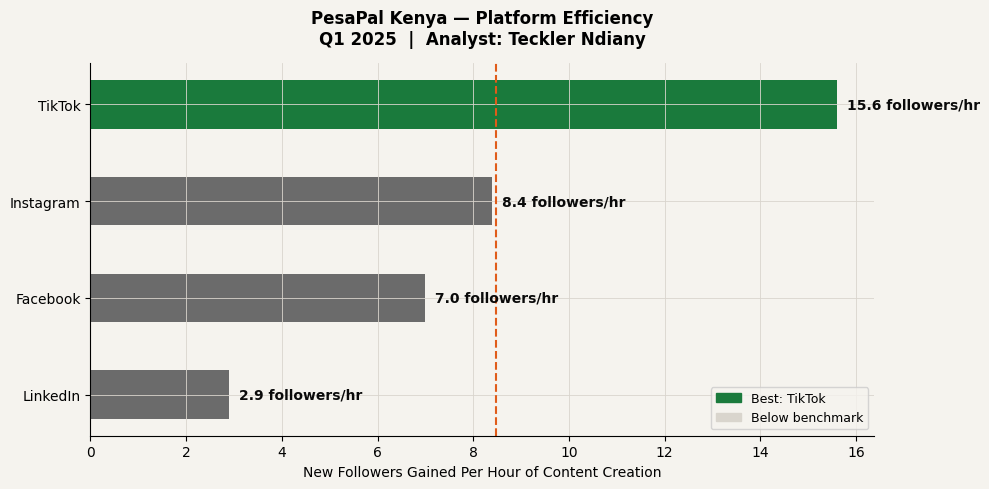

In [ ]:
GREEN  = "#1A7A3C"
ORANGE = "#E05C1A"
GREY   = "#6B6B6B"
LGREY  = "#D9D5CD"
BG     = "#F5F3EE"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.grid": True,
    "grid.color": LGREY,
    "grid.linewidth": 0.6,
})

# Sort ascending for horizontal bar chart
plat_sorted = platform.sort_values("Followers_Per_Hour", ascending=True)

colors = [
    GREEN if p == best_platform else (LGREY if platform.loc[platform["Platform"]==p, "Below_Benchmark"].values[0] else GREY)
    for p in plat_sorted["Platform"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plat_sorted["Platform"], plat_sorted["Followers_Per_Hour"],
               color=colors, height=0.5)

for bar, val in zip(bars, plat_sorted["Followers_Per_Hour"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} followers/hr", va="center",
            fontsize=10, fontweight="bold", color="#0A0A0A")

ax.axvline(x=plat_sorted["Followers_Per_Hour"].mean(),
           color=ORANGE, linestyle="--", linewidth=1.5, label="Average")

good = mpatches.Patch(color=GREEN, label=f"Best: {best_platform}")
low  = mpatches.Patch(color=LGREY, label="Below benchmark")
ax.legend(handles=[good, low], fontsize=9, loc="lower right")

ax.set_xlabel("New Followers Gained Per Hour of Content Creation", fontsize=10)
ax.set_title(f"{BRAND_NAME} — Platform Efficiency\nQ1 2025  |  Analyst: {ANALYST}",
             fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("chart1_platform_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2: Engagement by Content Type

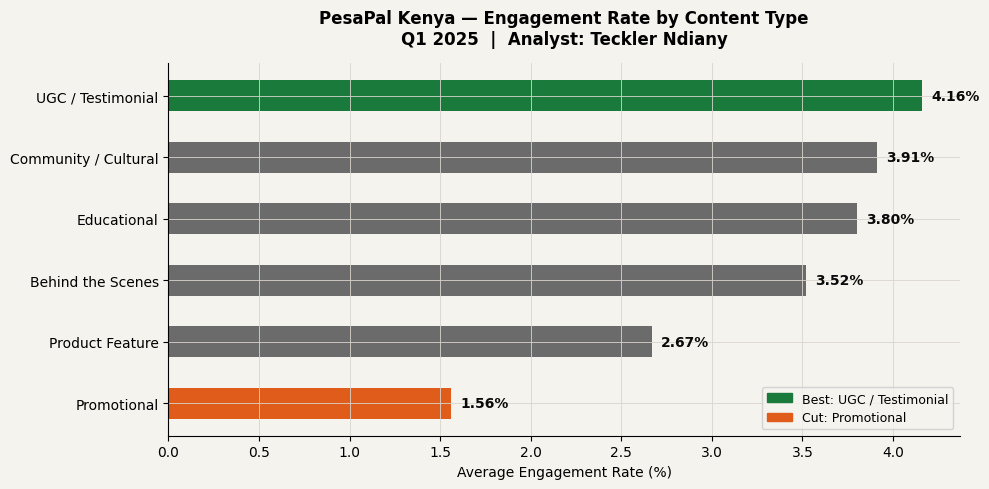

In [ ]:
content_sorted = content.sort_values("Avg_Eng_Rate", ascending=True)

bar_colors = [
    GREEN if ct == best_content else (ORANGE if ct == worst_content else GREY)
    for ct in content_sorted["Content Type"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(content_sorted["Content Type"], content_sorted["Avg_Eng_Rate"],
               color=bar_colors, height=0.5)

for bar, val in zip(bars, content_sorted["Avg_Eng_Rate"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", fontsize=10,
            fontweight="bold", color="#0A0A0A")

best_p  = mpatches.Patch(color=GREEN,  label=f"Best: {best_content}")
worst_p = mpatches.Patch(color=ORANGE, label=f"Cut: {worst_content}")
ax.legend(handles=[best_p, worst_p], fontsize=9)

ax.set_xlabel("Average Engagement Rate (%)", fontsize=10)
ax.set_title(f"{BRAND_NAME} — Engagement Rate by Content Type\nQ1 2025  |  Analyst: {ANALYST}",
             fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("chart2_content_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3: Weekly Follower Growth

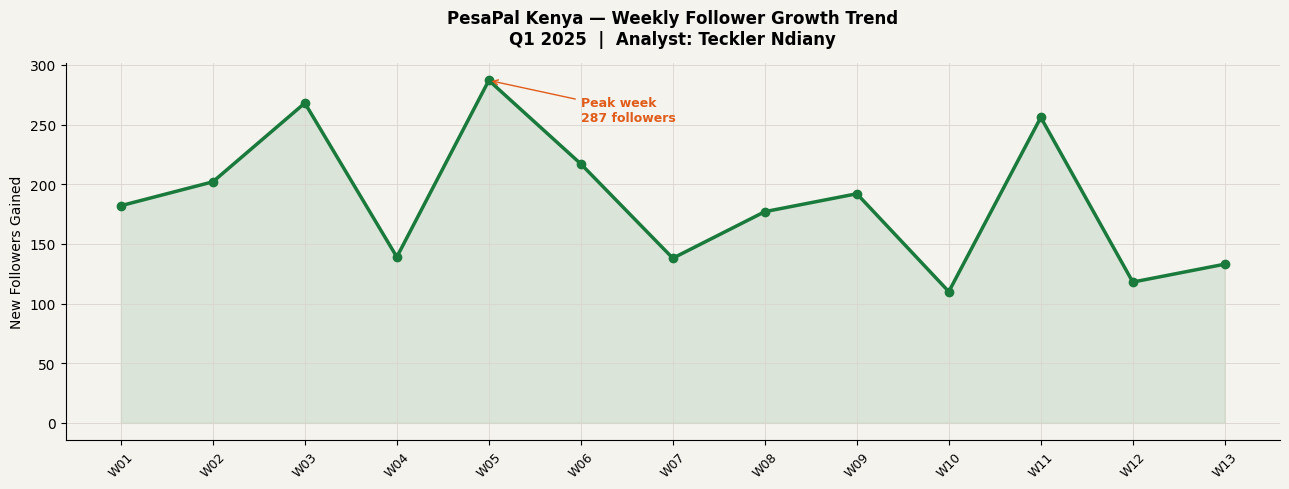

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(range(len(weekly)), weekly["Total_Followers"],
        color=GREEN, linewidth=2.5, marker="o", markersize=6)
ax.fill_between(range(len(weekly)), weekly["Total_Followers"],
                alpha=0.12, color=GREEN)

ax.set_xticks(range(len(weekly)))
ax.set_xticklabels(weekly["Week"], rotation=45, fontsize=9)
ax.set_ylabel("New Followers Gained", fontsize=10)
ax.set_title(f"{BRAND_NAME} — Weekly Follower Growth Trend\nQ1 2025  |  Analyst: {ANALYST}",
             fontsize=12, fontweight="bold", pad=14)

# Annotate peak week
peak_idx = weekly["Total_Followers"].idxmax()
ax.annotate(
    f"Peak week\n{int(weekly.loc[peak_idx,'Total_Followers']):,} followers",
    xy=(peak_idx, weekly.loc[peak_idx, "Total_Followers"]),
    xytext=(peak_idx + 1, weekly.loc[peak_idx, "Total_Followers"] * 0.88),
    arrowprops=dict(arrowstyle="->", color=ORANGE),
    fontsize=9, color=ORANGE, fontweight="bold"
)

plt.tight_layout()
plt.savefig("chart3_weekly_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 4: Engagement Heatmap (Platform × Content Type)

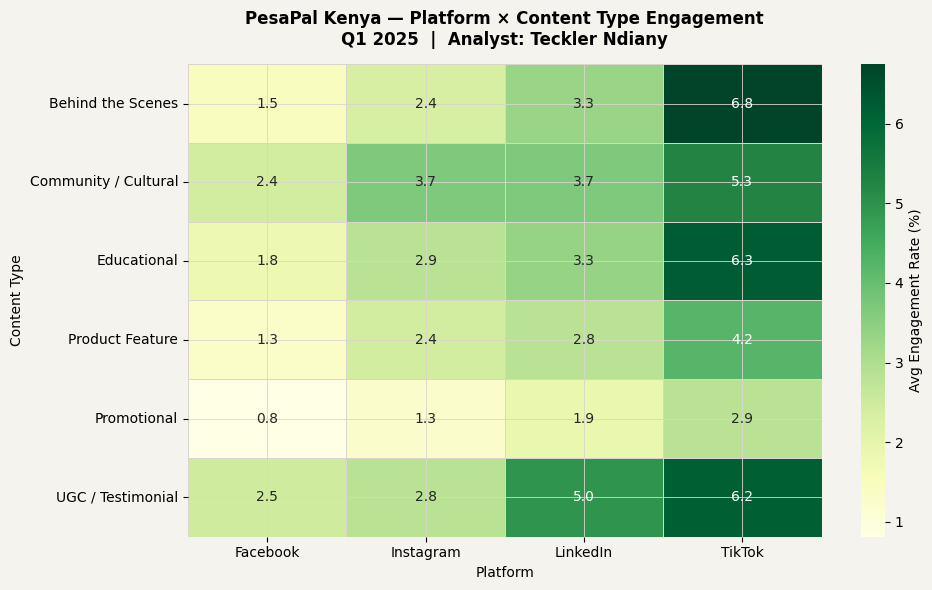

In [ ]:
pivot = df.pivot_table(
    values="Engagement Rate (%)",
    index="Content Type",
    columns="Platform",
    aggfunc="mean"
).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)

sns.heatmap(
    pivot,
    annot=True, fmt=".1f",
    cmap="YlGn",
    linewidths=0.5, linecolor=LGREY,
    ax=ax,
    cbar_kws={"label": "Avg Engagement Rate (%)"}
)

ax.set_title(f"{BRAND_NAME} — Platform × Content Type Engagement\nQ1 2025  |  Analyst: {ANALYST}",
             fontsize=12, fontweight="bold", pad=14)
ax.set_xlabel("Platform", fontsize=10)
ax.set_ylabel("Content Type", fontsize=10)
plt.tight_layout()
plt.savefig("chart4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
total_posts     = len(df)
total_reach     = int(df["Reach"].sum())
total_followers = int(df["New Followers"].sum())
avg_eng         = round(df["Engagement Rate (%)"].mean(), 2)
today           = datetime.today().strftime("%d %B %Y")

summary = f"""
╔══════════════════════════════════════════════════════╗
  {BRAND_NAME.upper()} — WEEKLY SOCIAL MEDIA SUMMARY
  Generated: {today}  |  Analyst: {ANALYST}
╚══════════════════════════════════════════════════════╝

OVERALL (90-DAY PERIOD)
  Total posts published : {total_posts:,}
  Total reach           : {total_reach:,}
  New followers gained  : {total_followers:,}
  Avg engagement rate   : {avg_eng:.2f}%

THE MAIN FINDING
  {best_platform} is your best platform.
     — {tiktok_fph:.1f} followers earned per hour of content creation
     — Driving {tiktok_follower_share}% of ALL new followers
     — With only {tiktok_post_share}% of total posts

   COST OF DISTRACTION
     — Weak platforms are using {wasted_hours:.0f} hours ({waste_pct}% of effort)
     — Those hours at TikTok efficiency = {opportunity_cost:,} additional
       followers you are NOT getting

   Best content type  : {best_content}
   Worst content type : {worst_content} — reduce frequency immediately

TOP 3 ACTIONS THIS WEEK
  1. Post on TikTok 5x this week — minimum
  2. Cut {worst_platform} to 1 post/week, move hours to TikTok
  3. Make your next 3 TikTok posts: {best_content} format

══════════════════════════════════════════════════════
"""

print(summary)

with open(f"summary_{datetime.today().strftime('%Y%m%d')}.txt", "w") as f:
    f.write(summary)


╔══════════════════════════════════════════════════════╗
  PESAPAL KENYA — WEEKLY SOCIAL MEDIA SUMMARY
  Generated: 26 April 2026  |  Analyst: Teckler Ndiany
╚══════════════════════════════════════════════════════╝

OVERALL (90-DAY PERIOD)
  Total posts published : 177
  Total reach           : 568,466
  New followers gained  : 2,419
  Avg engagement rate   : 3.13%

THE MAIN FINDING
  TikTok is your best platform.
     — 15.6 followers earned per hour of content creation
     — Driving 57.9% of ALL new followers
     — With only 25.4% of total posts

   COST OF DISTRACTION
     — Weak platforms are using 0 hours (0.0% of effort)
     — Those hours at TikTok efficiency = 0 additional
       followers you are NOT getting

   Best content type  : UGC / Testimonial
   Worst content type : Promotional — reduce frequency immediately

TOP 3 ACTIONS THIS WEEK
  1. Post on TikTok 5x this week — minimum
  2. Cut LinkedIn to 1 post/week, move hours to TikTok
  3. Make your next 3 TikTok posts: U